## Analazing the detected Nuclear Pore Complexes 


Steps: 
1. Loads the .hdf5 file together with metadata containing localizations
2. Render the localizations using Picasso Render and save as a png:
3. Calculate and visualise NPC features and fit ellipse to NPC localisations - function definitions
- Render the localizations
- Segment nuclei region
- Spatial filtering -filter the localizations based on the location within nuclei 
- Select some example NPC
- Find similar NPC 
- Clean the detection from the false positives



#### Load the python libraries:

In [1]:
import os
import os.path as ospath
import numpy as np
import matplotlib.pyplot as plt
import picasso_addon
from picasso import io, aim, postprocess, render
from pathlib import Path

from scipy.ndimage import gaussian_filter
from sklearn.neighbors import KernelDensity

In [2]:
%matplotlib inline
def cleanup():
    """Run before heavy analysis"""
    import gc, matplotlib.pyplot as plt
    plt.close('all')
    gc.collect()
    print("🧹 Cleaned")
    
def plot_image(image, size=30):    
    """
    Plot a grayscale image in the original size - takes time
    """
    fig = plt.figure(figsize=(size, size))
    ax1 = plt.axis("off")
    ax1 = plt.subplot(1, 1, 1) 
    ax1.imshow(image, cmap='gray')  

#### Set the path to the input file: 

In [ ]:
# Set the path to your HDF5 file
from picasso import io, postprocess

folder = 'C:/Users/krili463/Documents/Data/AI4LIfe_Pr18_DNApaint/Data2/Localizations_files/'
file = "nup107.ome_locs_render_nucleusfiltered_picked.hdf5"
picked_image_path = Path(os.path.join(folder, file))

print(picked_image_path.exists())
print(picked_image_path) 

True
C:\Users\krili463\Documents\Data\AI4LIfe_Pr18_DNApaint\Data2\Localizations_files\nup107.ome_locs_render.hdf5


### 1. Data loading - loads the .hdf5 and .yaml file of picked localizations previously assigned to NPCs using GUI version of Picasso 

In [7]:
picked_locs, picked_info = io.load_locs(picked_image_path)

print(picked_locs.shape)
picked_locs


(870578, 12)


,frame,x,y,photons,sx,sy,bg,lpx,lpy,ellipticity,net_gradient,group
0,29,293.301575,305.734924,4294.232422,1.256095,1.306713,55.855446,0.042373,0.044397,0.038737,235114.671875,0
1,30,293.227722,305.727264,6421.118164,1.289627,1.259177,58.593372,0.034423,0.033512,0.023611,354574.125000,0
2,31,293.274231,305.757141,6425.472168,1.202420,1.249407,69.439728,0.032309,0.033742,0.037607,384614.187500,0
3,32,293.241364,305.716217,6559.046387,1.295722,1.285720,66.607941,0.034597,0.034292,0.007719,361899.531250,0
4,33,293.271484,305.683228,3105.594238,1.338532,1.335257,55.219784,0.056200,0.056027,0.002446,166767.921875,0
...,...,...,...,...,...,...,...,...,...,...,...,...
870573,18481,398.645691,379.986694,4592.192383,1.234716,1.338856,48.464569,0.039288,0.043115,0.077782,257161.015625,1377
870574,18840,398.865326,379.509949,12111.916016,1.260266,1.813827,49.985592,0.023207,0.034426,0.305189,502429.187500,1377
870575,18841,399.085571,380.201385,6133.901367,1.185026,1.251065,54.105312,0.031973,0.033941,0.052786,388660.156250,1377
870576,19169,398.249603,379.770599,2124.338135,2.650924,1.950911,29.964611,0.169638,0.107511,0.264064,32053.453125,1377


### 2. Render the localizations using Picasso Render and save as a png:

In [9]:
# Set the rendering parameters:
viewport =  (0, 0), (700, 700)   # (y_min, x_min), (y_max, x_max) // (height, width)
oversampling = 10                # number of display pixels per camera pixel, display pixel size = camera pixel size / oversampling
blur_method = "smooth"           # one pixel blur
picked_locs_len_x, picked_locs_image = render.render(picked_locs, viewport=viewport, oversampling=oversampling, blur_method=blur_method)

# Save into png file
plt.imsave('data/overview_render_rgb_picked_locs.png', picked_locs_image, cmap='hot', vmax=1)
plt.imsave('data/overview_render_gray_picked_locs.png', picked_locs_image, cmap='gray', vmax=1)
plt.close()

#### Plot the rendered image:

(7000, 7000, 4) float32


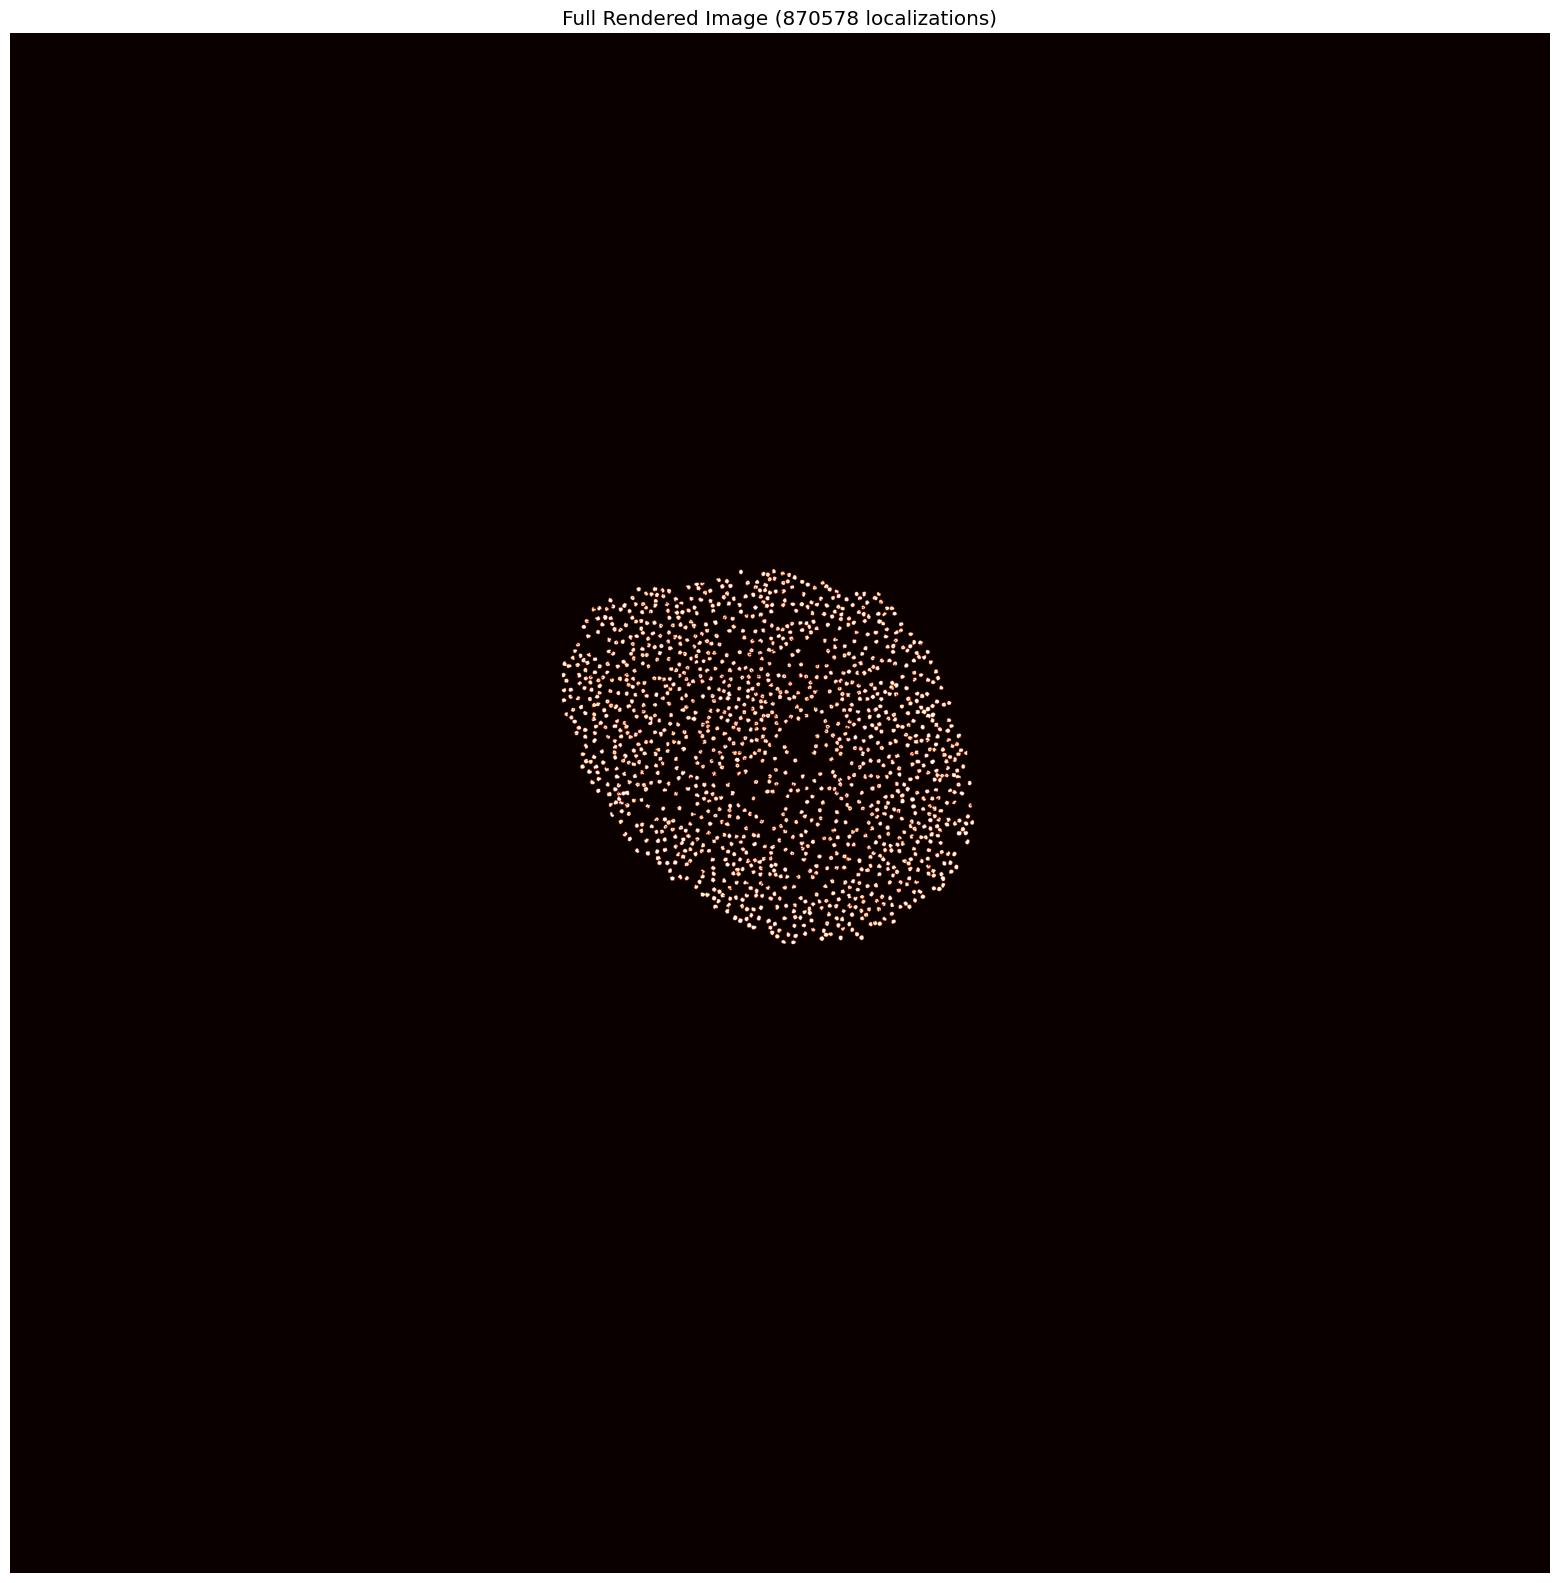

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # or from matplotlib import image as mpimg

picked_render_img = mpimg.imread("data/overview_render_rgb_picked_locs.png")  # path to your PNG
print(picked_render_img.shape, picked_render_img.dtype)  # optional check

plt.figure(figsize=(20, 20))
plt.title('Full Rendered Image ('+ str(picked_locs.shape[0]) +' localizations)')
plt.imshow(picked_render_img, cmap="gray")  # drop cmap if the PNG is already colored
plt.axis("off")
plt.show()

#### Read the picks center location from yalm and load the centers of the picks and the diameter

In [12]:
import yaml

with open("C://Users/krili463/Documents/Data/AI4LIfe_Pr18_DNApaint/Data2/Localizations_files/nup107.ome_locs_render_nucleusfiltered_picks.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data)
data["Centers"]

{'Centers': [[293.2045261400413, 305.3221686963077], [296.6401711457644, 302.5409322631033], [288.4600639892809, 295.5060401085275], [287.83837584538816, 299.0725668287543], [271.6417636755508, 303.84974940814067], [271.052795960284, 310.39383513332746], [261.138506086626, 297.7637496837169], [273.57226896448094, 294.0990616776123], [307.4379125923226, 293.6409756768493], [313.91655746025754, 292.299438103186], [317.7448476094918, 311.17912542034986], [326.8738471961274, 296.749416396313], [327.037449339257, 321.02797443675604], [301.8099988686619, 322.1731894386637], [280.6726019763086, 318.14857671767385], [261.4984308015113, 319.8827594348483], [251.53844120135363, 291.8378013959391], [252.12043183174225, 286.7383092183771], [252.94946860374415, 294.3593262480499], [251.8496001184834, 298.7636502764613], [251.7888728762136, 303.33517900485435], [254.11948910788382, 287.7245418395574], [252.93169487847223, 309.638599537037], [255.86817286036037, 284.051537865991], [254.73442897236615

[[293.2045261400413, 305.3221686963077],
 [296.6401711457644, 302.5409322631033],
 [288.4600639892809, 295.5060401085275],
 [287.83837584538816, 299.0725668287543],
 [271.6417636755508, 303.84974940814067],
 [271.052795960284, 310.39383513332746],
 [261.138506086626, 297.7637496837169],
 [273.57226896448094, 294.0990616776123],
 [307.4379125923226, 293.6409756768493],
 [313.91655746025754, 292.299438103186],
 [317.7448476094918, 311.17912542034986],
 [326.8738471961274, 296.749416396313],
 [327.037449339257, 321.02797443675604],
 [301.8099988686619, 322.1731894386637],
 [280.6726019763086, 318.14857671767385],
 [261.4984308015113, 319.8827594348483],
 [251.53844120135363, 291.8378013959391],
 [252.12043183174225, 286.7383092183771],
 [252.94946860374415, 294.3593262480499],
 [251.8496001184834, 298.7636502764613],
 [251.7888728762136, 303.33517900485435],
 [254.11948910788382, 287.7245418395574],
 [252.93169487847223, 309.638599537037],
 [255.86817286036037, 284.051537865991],
 [254.73

### Visualize the picked NPC with circles

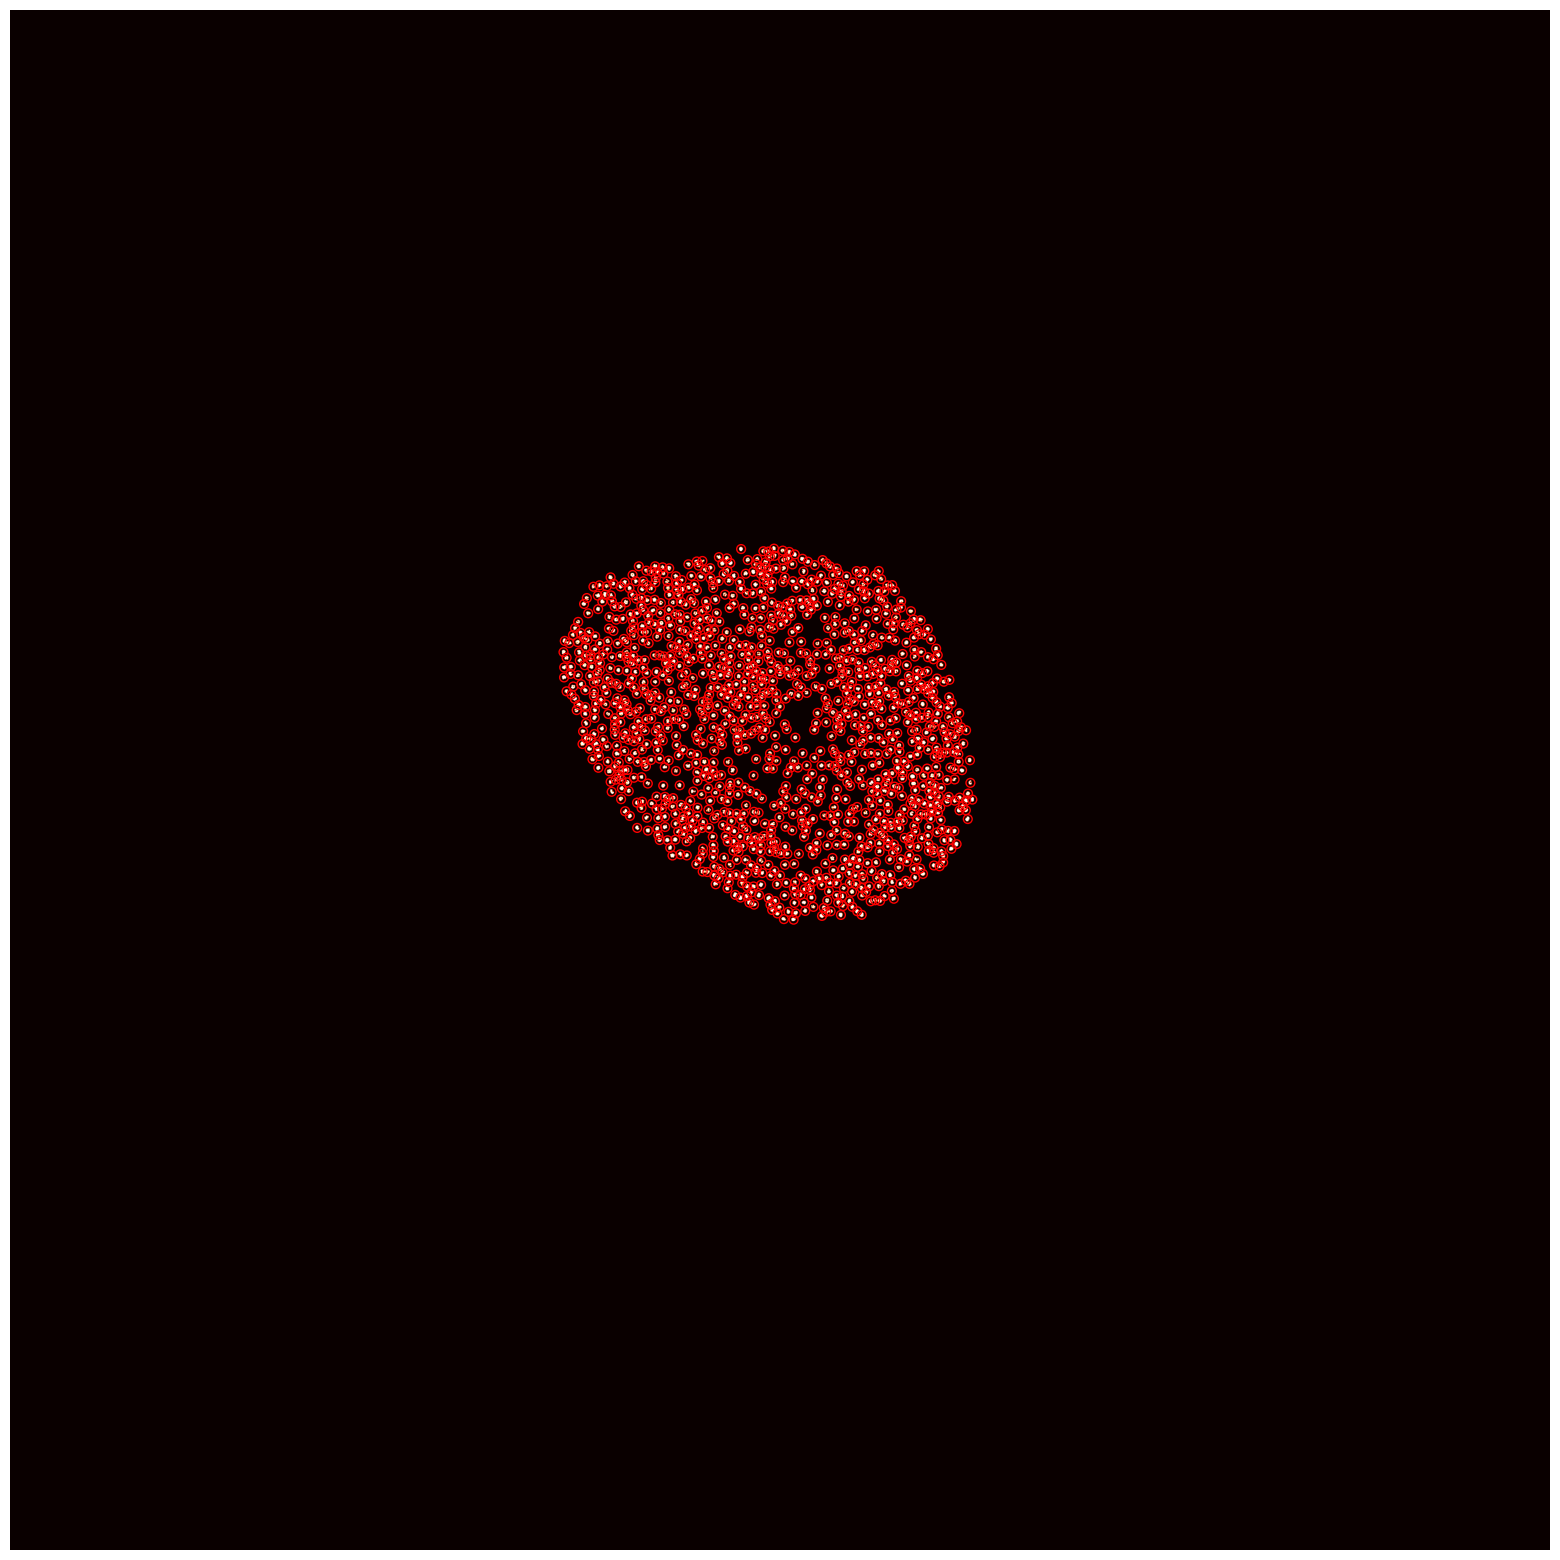

In [14]:
from matplotlib.patches import Circle

centers = data["Centers"]

fig, ax = plt.subplots(figsize=(20, 20))
ax.imshow(picked_render_img, cmap="gray")

for x, y in centers:
    circ = Circle((x*10, y*10), radius=20, edgecolor="red", facecolor="none", linewidth=1)
    ax.add_patch(circ)

ax.set_axis_off()
plt.show()


### 3. Calculate NPC features and shape descriptors by fitting an ellipse to NPC localizations

#### Define the functions:

In [17]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

def fit_ellipse_to_group(locs, plot=False):
    """Simplified, more robust ellipse fitting."""
    x = locs['x'].values
    y = locs['y'].values
    
    if len(x) < 6:    # at least 6 points for a reliable fit
        return None
    
    # Simple moment-based ellipse (more robust than algebraic)
    x_mean = np.mean(x)      # Center X
    y_mean = np.mean(y)      # Center Y
    x_var = np.var(x)        # Spread in X;   High x_var = wide spread in X
    y_var = np.var(y)        # Spread in Y
    xy_cov = np.cov(x, y)[0,1]  # Correlation between X and Y;   High xy_cov = points tilted ↘️ (positive correlation)
    
    # Eigenvalues/vectors for ellipse axes
    cov = np.array([[x_var, xy_cov], [xy_cov, y_var]])    # This matrix encodes: spread + orientation + correlation of your points.
    eigvals, eigvecs = np.linalg.eigh(cov)
    
    # True 1σ ellipse (68% coverage)
    scales = 1                               # scales = [1.0, 1.2, 1.5, 2.0]  # 68%, 78%, 86%, 95%
    semi_major = 2 * np.sqrt(eigvals[1]) * scales   # full width (-1σ to +1σ, ~68% coverage) *1.5 = arbitrary scaling to ~86% coverage; 
    semi_minor = 2 * np.sqrt(eigvals[0]) * scales
    
    angle = np.degrees(np.arccos(np.clip(eigvecs[0,1], -1, 1)))  # Angle of major axis; 0° = horizontal, 90° = vertical
    
    # Residuals (distance to ellipse boundary)
    distances = np.sqrt((x-x_mean)**2 + (y-y_mean)**2)
    confidence = np.std(distances)
 
    return {
        'center_x': x_mean, 'center_y': y_mean,
        'semi_major': semi_major, 'semi_minor': semi_minor,
        'angle_deg': angle,
        'eccentricity': 1 - np.sqrt(eigvals[0]/eigvals[1]),
        'fit_confidence': confidence
    }

def measure_npc_features(grouped_locs):
    """
    Compute comprehensive NPC features from grouped localizations and compute additional features from ellipse fitted to each NPC cluster.
    
    Parameters
    ----------
    grouped_locs : pandas.groupby object
        picked_locs.groupby('group') from Picasso autopick
        
    Returns
    -------
    npc_features : pd.DataFrame
        One row per NPC with all computed features
    """
    
    features = []
    
    for group_id, locs in grouped_locs:
        if len(locs) < 10:  # Skip tiny groups
            continue
            
        # 1. Center position
        median_center_x = locs['x'].median()
        median_center_y = locs['y'].median()
        mean_center_x = locs['x'].mean()
        mean_center_y = locs['y'].mean()

        center_x, center_y = median_center_x, median_center_y  # use median for distance calculations to reduce outlier impact
        
        # 2. Radius (distance from center)
        radii = np.linalg.norm(locs[['x', 'y']] - [center_x, center_y], axis=1)
        mean_radius = radii.mean()
        radius_std = radii.std()  # Ring thickness proxy

        # 3. Number of localizations
        n_locs = len(locs)
        
        # 4. Localization quality
        median_photons = locs['photons'].median()
        median_precision = np.median(np.sqrt(locs['sx']**2 + locs['sy']**2))
        mean_ellipticity = locs['ellipticity'].mean()   # means ellipticity of each separate point, not of the cluster as a whole
        mean_bg = locs['bg'].median()
        
        # 5. Angular coverage (0-360 degrees) - how completely your NPC ring is "filled" around the circle (0-100%)
        slices = 360  # Make 36 "slices" around the circle (10° each)
        angles = np.arctan2(locs['y'] - center_y, locs['x'] - center_x)
        angles_deg = np.degrees(angles) % 360
        angular_coverage = np.sum(np.histogram(angles_deg, bins=slices, range=(0,360))[0] > 0) / slices * 100

        
        # 6. Compactness (via convex hull ratio)  /  fraction of the bounding box filled by the convex hull of the points
        # Values closer to 1 mean the hull almost fills the bounding box; lower values mean the points are more elongated, sparse, or ring-like
        points = np.column_stack([locs['x'], locs['y']])
        hull = ConvexHull(points)  # calculates the convex hull of the points and stores the vertices of convex hull in hull.vertices
        hull_points = points[hull.vertices]

        # Shoelace formula for polygon area
        area_hull = 0.5 * np.abs(np.sum(hull_points[:,0] * np.roll(hull_points[:,1], -1) - 
                                       hull_points[:,1] * np.roll(hull_points[:,0], -1)))
        
        # Bounding box area
        bbox_area = (locs['x'].max() - locs['x'].min()) * (locs['y'].max() - locs['y'].min())
        compactness = area_hull / bbox_area if bbox_area > 0 else 0
        
        # 7a. Ring density (locs per ring circumference)
        ring_density = n_locs / (2 * np.pi * mean_radius)
        
        # 7b.Area density (locs per area)
        area_nm2 = np.pi * mean_radius**2
        area_density = n_locs / area_nm2
        
        # 8. Radius distribution kurtosis (how ring-like)
        radius_kurt = stats.kurtosis(radii)

        # Ringness proxy: fraction of locs in outer ring (80-120% of mean radius)
        ring_mask = (radii > 0.8*mean_radius) & (radii < 1.2*mean_radius)
        ring_fraction = ring_mask.mean()

        # 9. Additional features from ellipse fitting
        ellipse_features = fit_ellipse_to_group(locs)


        # Store features
        features.append({
            'group_id': group_id,
            'n_locs': n_locs,
            'median_center_x': median_center_x,
            'median_center_y': median_center_y,
            'mean_center_x': mean_center_x,
            'mean_center_y': mean_center_y,
            'mean_radius': mean_radius,
            'radius_std': radius_std,
            'median_photons': median_photons,
            'median_loc_precision': median_precision,
            'mean_loc_ellipticity': mean_ellipticity,
            'mean_bg': mean_bg,
            'angular_coverage_pct': angular_coverage,
            'compactness': compactness,
            'ring_density': ring_density,
            'area_density': area_density,
            'radius_kurtosis': radius_kurt,
            'ring_fraction': ring_fraction,
            'ellipse_center_x': ellipse_features['center_x'],
            'ellipse_center_y': ellipse_features['center_y'],
            'ellipse_semi_major': ellipse_features['semi_major'],
            'ellipse_semi_minor': ellipse_features['semi_minor'],
            'ellipse_angle_deg': ellipse_features['angle_deg'],
            'ellipse_eccentricity': ellipse_features['eccentricity'],
            'ellipse_fit_confidence': ellipse_features['fit_confidence']
        })
    
    return pd.DataFrame(features)

def visualize_npc_features(group_id, picked_locs, npc_features):
    """Complete NPC diagnostic using ONLY precomputed npc_features"""
    
    # 1. Get data
    locs_one = picked_locs[picked_locs['group'] == group_id]
    feat_row = npc_features[npc_features['group_id'] == group_id].iloc[0]
    
    # 2. Extract ALL precomputed values (no recalculation!)
    mean_cx, mean_cy = feat_row['mean_center_x'], feat_row['mean_center_y']
    median_cx, median_cy = feat_row['median_center_x'], feat_row['median_center_y']
    mean_radius = feat_row['mean_radius']
    ellipse_cx, ellipse_cy = feat_row['ellipse_center_x'], feat_row['ellipse_center_y']
    semi_major, semi_minor = feat_row['ellipse_semi_major'], feat_row['ellipse_semi_minor']
    ellipse_angle = feat_row['ellipse_angle_deg']
    angular_coverage = feat_row['angular_coverage_pct']
    
    # 3. Plot with everything
    fig, ax = plt.subplots(figsize=(25, 10))

    #---------------------
    # LEFT: Cartesian view (features)
    ax_cart = plt.subplot(1, 2, 1)

    # Points
    ax_cart.scatter(locs_one['x'], locs_one['y'], s=12, c='red', alpha=1, zorder=3)

    # Centers 
    ax_cart.scatter(mean_cx, mean_cy, c='blue', s=200, marker='+', linewidth=0.6, zorder=5, label='Mean center')
    ax_cart.scatter(median_cx, median_cy, c='red', s=200, marker='+', linewidth=0.6, zorder=5, label='Median center')
    ax_cart.scatter(ellipse_cx, ellipse_cy, c='green', s=20, marker='o', linewidth=0.5, zorder=5, label='Ellipse center')
    
    # Ellipse 
    ell_patch = Ellipse((ellipse_cx, ellipse_cy), 2*semi_major, 2*semi_minor,
                       angle=ellipse_angle, fill=False, alpha=0.5, edgecolor='green', 
                       linewidth=3, zorder=3, label='Fitted ellipse')
    ax_cart.add_patch(ell_patch)
    
    # Convex hull (quick recalc - only visualization)
    points = locs_one[['x','y']].values
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            ax_cart.add_patch(Polygon(hull_pts, alpha=0.4, facecolor='orange', 
                                edgecolor='darkorange', linewidth=2, zorder=2, label='Convex hull'))
        except:
            pass
   
    # Ring mask points 
    center = np.array([median_cx, median_cy])
    radii = np.linalg.norm(locs_one[['x', 'y']].values - center, axis=1)
    ring_mask = (radii > 0.8*mean_radius) & (radii < 1.2*mean_radius)
    ring_locs = locs_one[ring_mask]
    ax_cart.scatter(ring_locs['x'], ring_locs['y'], s=30, c='cyan', edgecolor='darkcyan', 
               linewidth=1, zorder=2, label=f'Ring mask ({feat_row["ring_fraction"]:.0%})')
    
    ring_circle_out = Circle((median_cx, median_cy), 1.2*mean_radius,
                       fill=False, alpha=0.3, edgecolor='darkcyan', 
                       linewidth=2, zorder=3, label='Outer ring mask boundary')
    ax_cart.add_patch(ring_circle_out)

    ring_circle_in = Circle((median_cx, median_cy), 0.8*mean_radius,
                       fill=False, alpha=0.3, edgecolor='cyan', 
                       linewidth=2, zorder=3, label='Inner ring mask boundary')
    ax_cart.add_patch(ring_circle_in)
    
    # Formatting
    ax_cart.set_aspect('equal')
    ax_cart.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_cart.grid(True, alpha=0.3)
    
    # COMPREHENSIVE title from npc_features
    title = (f"NPC {group_id} | "
            f"N={feat_row['n_locs']} | "
            f"R={feat_row['mean_radius']:.1f}±{feat_row['radius_std']:.1f} | "
            f"RingFrac={feat_row['ring_fraction']:.0%} | "
            f"AngCov={feat_row['angular_coverage_pct']:.0f}% | "
            f"Ecc={feat_row['ellipse_eccentricity']:.2f} | "
            f"Dens={feat_row['ring_density']:.2f}")
    
    ax_cart.set_title(title, fontsize=11, pad=20)

     #---------------------
    # RIGHT: Polar angular coverage
    ax_polar = plt.subplot(1, 2, 2, projection='polar')

    angles = (np.arctan2(locs_one['y']-median_cy, locs_one['x']-median_cx))  # angles in radians 
    radius = np.sqrt((locs_one['x'] - median_cx)**2 + (locs_one['y'] - median_cy)**2)  #
    #scatter in red color the localisations at their radius and angle
    ax_polar.scatter(angles, radius, s=20, c='red', label='Real localizations')
    # scatter in blue color the localisations at the mean radius to visualize angular coverage
    ax_polar.scatter(angles, np.ones(len(locs_one))*(np.max(radius)+0.05), s=20, c='blue', label='Localisations projected into angular coverage')
    ax_polar.set_title(f"NPC {group_id}: {angular_coverage:.0f}% coverage")
    ax_polar.legend(bbox_to_anchor=(0.25, 0), loc='lower right')

    plt.tight_layout()
    plt.show()


#### Measure NPC features and shape descriptors

- For calculating the center of NPC the median of localisations makes more sense - it is less sensitive to outliers.
- For fitting an ellipse the mean of localisations works better - othersiwe the ellipse is not taking into account outliers and then the fit looks weird.

In [18]:
npc_features = measure_npc_features(picked_locs.groupby('group'))
npc_features

,group_id,n_locs,median_center_x,median_center_y,mean_center_x,mean_center_y,mean_radius,radius_std,median_photons,median_loc_precision,...,area_density,radius_kurtosis,ring_fraction,ellipse_center_x,ellipse_center_y,ellipse_semi_major,ellipse_semi_minor,ellipse_angle_deg,ellipse_eccentricity,ellipse_fit_confidence
0,0,630,293.314941,305.398682,293.275848,305.385132,0.532887,0.165485,4301.007812,1.804710,...,706.187866,-0.335887,0.474603,293.275848,305.385132,0.883149,0.677208,173.720070,0.233189,0.154301
1,1,570,297.014648,302.511322,296.813385,302.420135,0.587677,0.238811,4214.952637,2.155088,...,525.348511,-0.781980,0.301754,296.813385,302.420135,0.938289,0.730707,162.952049,0.221235,0.149134
2,2,713,288.203796,295.440247,288.333801,295.458099,0.560465,0.225146,4566.388184,1.776873,...,722.506958,-0.670827,0.329593,288.333801,295.458099,0.862147,0.804400,145.234932,0.066981,0.167898
3,3,661,287.890533,298.979553,287.809143,299.053558,0.573588,0.174565,4624.076660,1.783703,...,639.515991,0.203095,0.534039,287.809143,299.053558,0.915673,0.742309,91.793766,0.189329,0.136339
4,4,808,271.327850,303.974335,271.472076,303.870178,0.548816,0.252768,4080.301514,1.742525,...,853.903259,-0.838403,0.222772,271.472076,303.870178,0.851046,0.780674,160.102040,0.082688,0.162823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1373,1373,433,348.277802,319.736603,348.257202,319.618469,0.503911,0.229474,5477.740723,1.766827,...,542.787476,-0.461081,0.413395,348.257202,319.618469,0.859657,0.655622,110.380209,0.237345,0.189619
1374,1374,777,400.224518,369.353302,400.246979,369.397125,0.512808,0.178017,5287.109375,1.748164,...,940.507629,-0.133367,0.535393,400.246979,369.397125,0.806976,0.719535,45.979785,0.108356,0.169461
1375,1375,823,412.478760,300.205963,412.447571,300.274139,0.519480,0.204612,2997.525146,1.761524,...,970.760742,-0.316279,0.368165,412.447571,300.274139,0.872692,0.680309,159.917972,0.220448,0.200948
1376,1376,484,351.425049,259.993225,351.456696,260.019836,0.521160,0.232996,2760.394287,1.808428,...,567.222412,-0.882588,0.293388,351.456696,260.019836,0.881865,0.720451,134.346301,0.183037,0.224171


### 4. Visualize and examine NPC features and fitted ellipse to NPC localizations

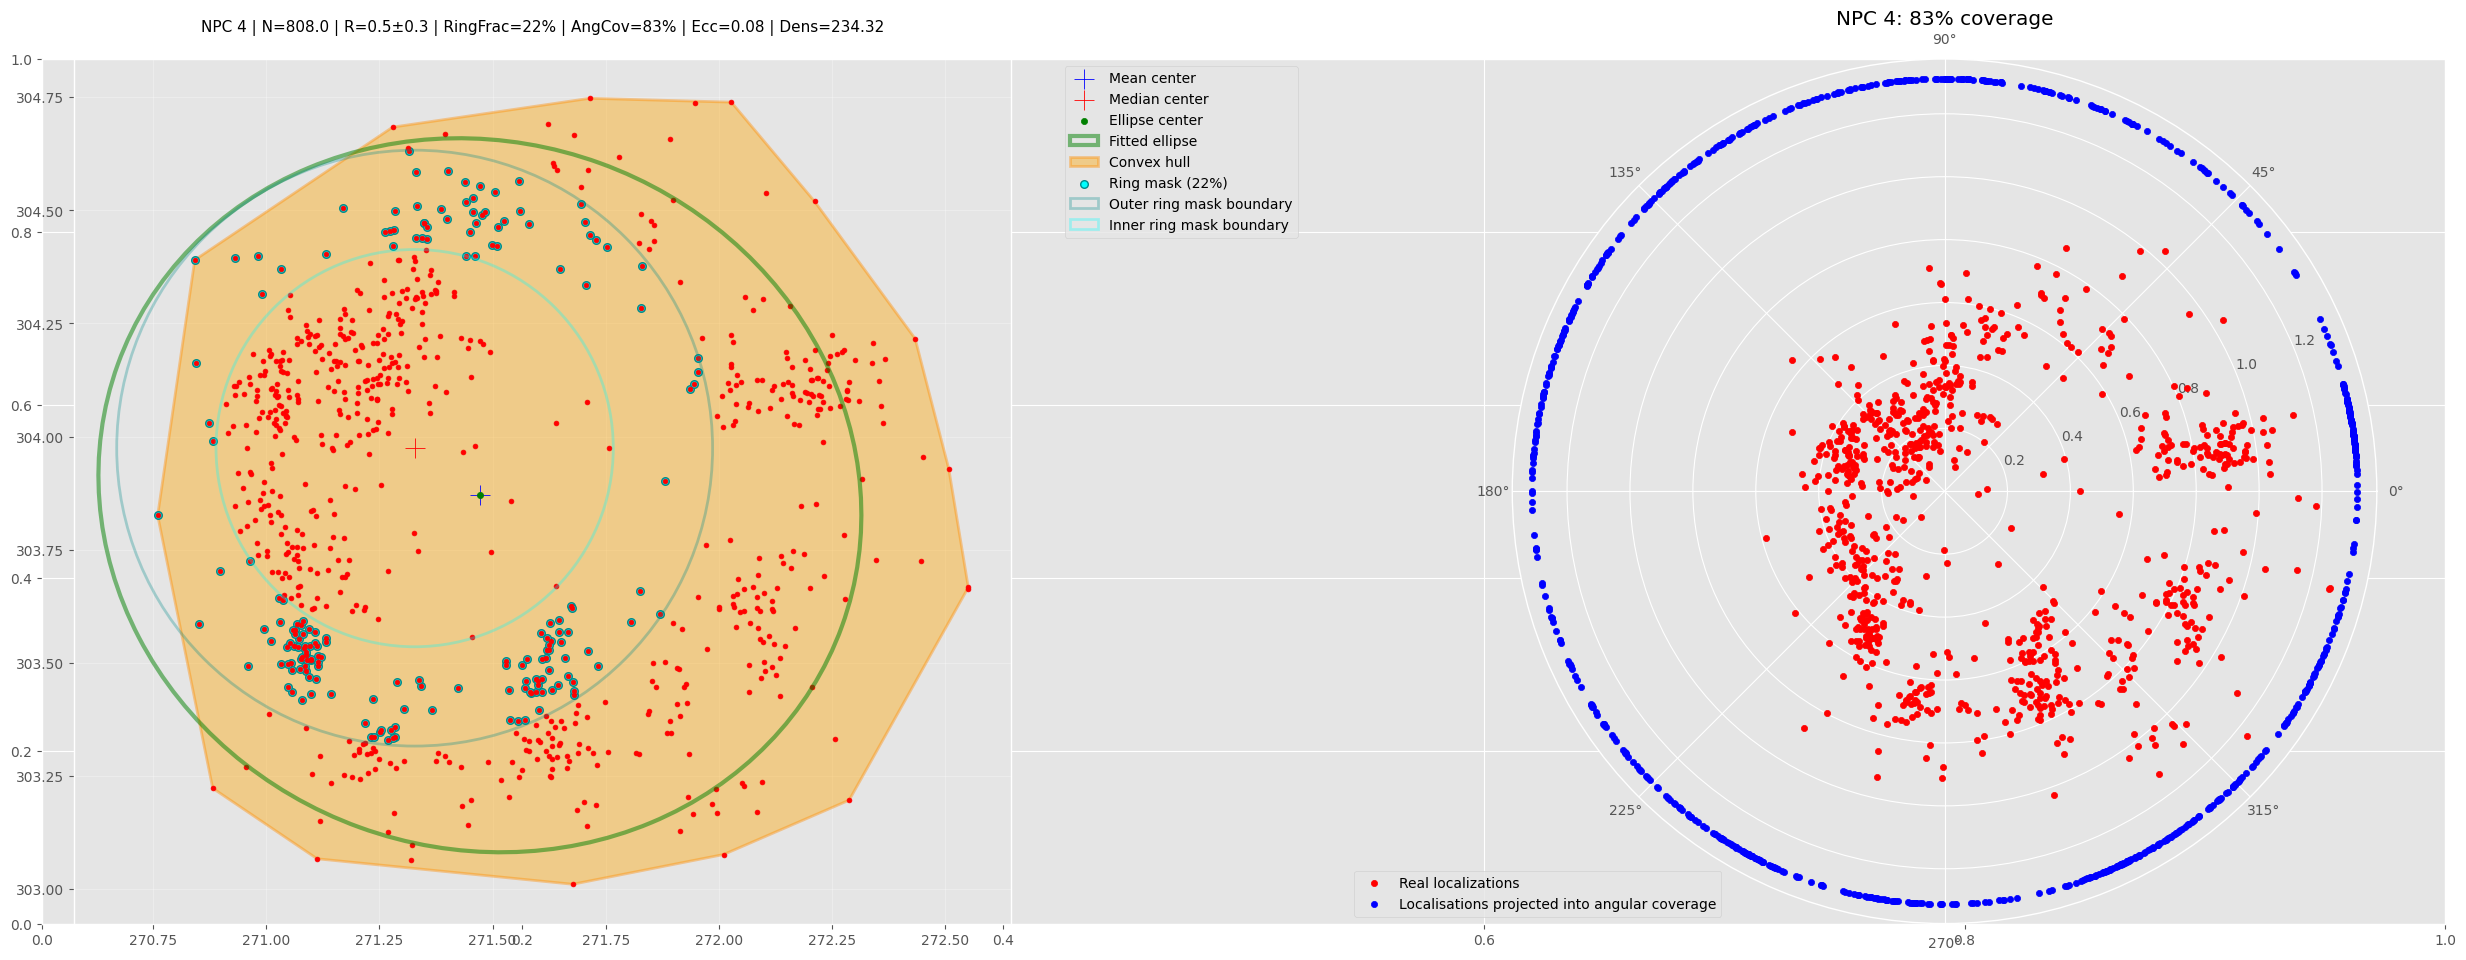

In [ ]:
visualise_group_id = 4  # 502  # change to any valid group_id from npc_features
visualize_npc_features(visualise_group_id, picked_locs, npc_features)

Plot the fitting ellipses on the data and save it:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


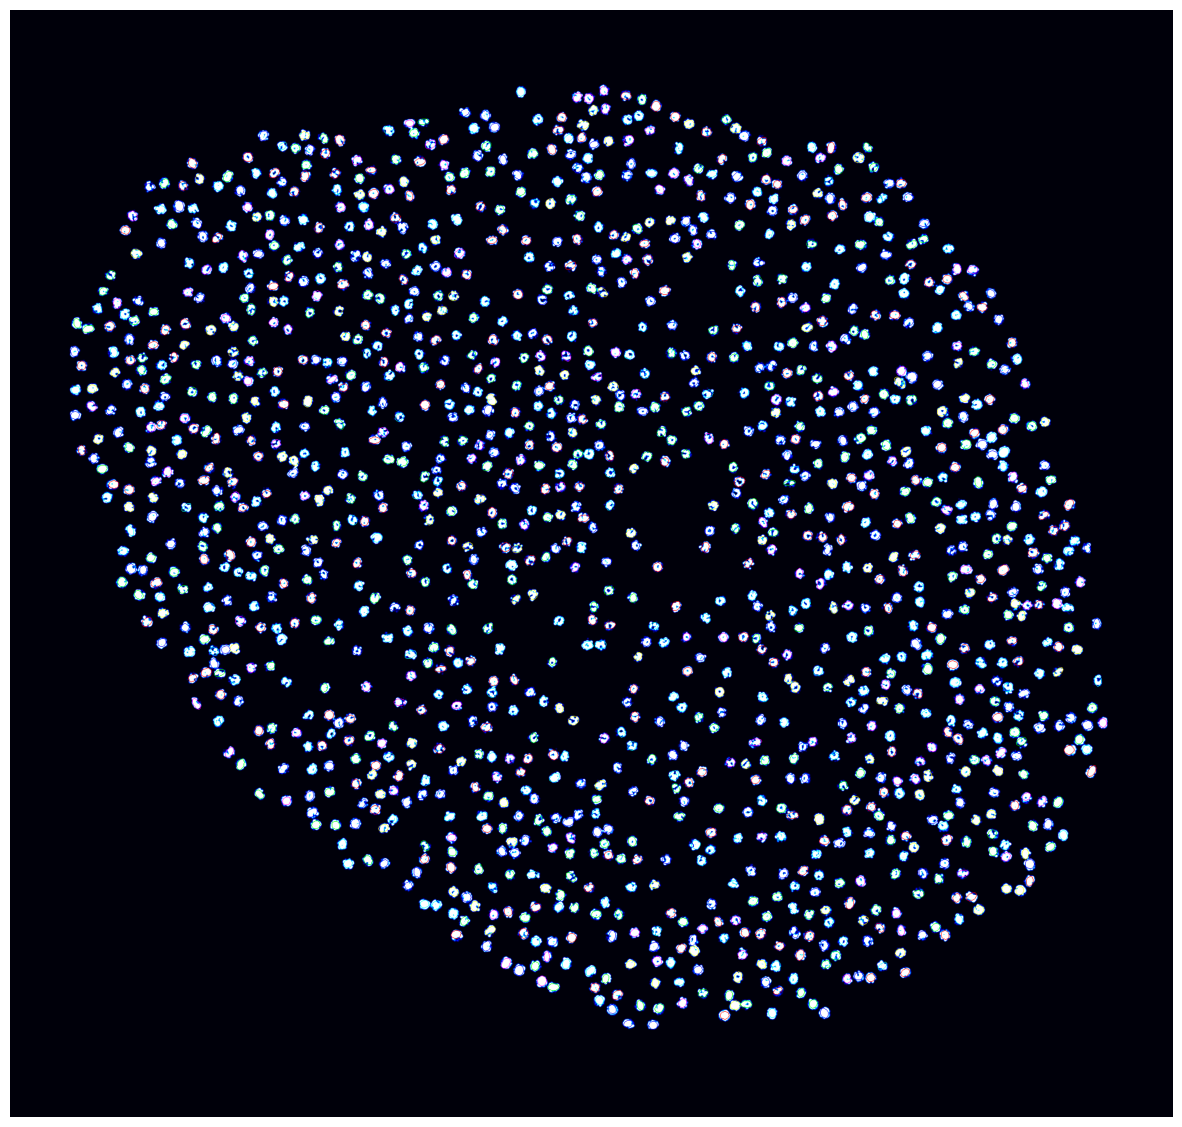

✅ Saved at original resolution: (7000, 7000, 3)


In [24]:
import cv2

def draw_npc_ellipses(
    picked_render_img,
    npc_features,
    oversampling=1.0,
    output_dir='output/',
    crop_y=(2300, 4300),
    crop_x=(2400, 4500),
    out_png='npc_ellipses_cv2.png',
    out_tif='npc_ellipses_cv2.tif',
    thickness=1,
    save_formats=['png', 'tif']
):
    img = picked_render_img.copy()

    if len(img.shape) == 2:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 3:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = img.copy()

    colors = [
        (255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255),
        (0,255,255), (128,0,0), (0,128,0), (0,0,128), (128,128,0)
    ] * 2

    for i, row in npc_features.iterrows():
        cx = int(row["ellipse_center_x"] * oversampling)
        cy = int(row["ellipse_center_y"] * oversampling)
        width = int(2 * row["ellipse_semi_major"] * oversampling)
        height = int(2 * row["ellipse_semi_minor"] * oversampling)
        angle = int(row["ellipse_angle_deg"])

        color = colors[i % len(colors)]

        cv2.ellipse(
            img_bgr,
            center=(cx, cy),
            axes=(width // 2, height // 2),
            angle=angle,
            startAngle=0,
            endAngle=360,
            color=color,
            thickness=thickness,
            lineType=cv2.LINE_AA
        )
    
    if len(picked_render_img.shape) == 2:
        result_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        result_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    cropped = result_img[crop_y[0]:crop_y[1], crop_x[0]:crop_x[1]]

     # Create output directory
    Path(output_dir).mkdir(exist_ok=True)

    base_name = 'npc_ellipses'
    saved_files = []
    
    for fmt in save_formats:
        if fmt == 'png':
            cv2.imwrite(f'{output_dir}/{base_name}.png', cropped)
            saved_files.append(f'{output_dir}/{base_name}.png')
        elif fmt == 'tif':
            cv2.imwrite(f'{output_dir}/{base_name}.tif', cropped)
            saved_files.append(f'{output_dir}/{base_name}.tif')
        elif fmt == 'jpg':
            cv2.imwrite(f'{output_dir}/{base_name}.jpg', cropped, [cv2.IMWRITE_JPEG_QUALITY, 95])
            saved_files.append(f'{output_dir}/{base_name}.jpg')


    plt.figure(figsize=(15, 15))
    plt.imshow(cropped)
    plt.axis('off')
    plt.show()

    print(f"✅ Saved at original resolution: {result_img.shape}")
    return result_img, cropped  

result_img, cropped = draw_npc_ellipses(
    picked_render_img,
    npc_features,
    oversampling=oversampling,
    output_dir='npc_ellipses/',
    save_formats=['png', 'tif']
)

Plot the fitting ellipses on the data with the NPC ID's and save it:

2932 3053 17 13 173 10.0
2968 3024 18 14 162 10.0
2883 2954 17 16 145 10.0
2878 2990 18 14 91 10.0
2714 3038 17 15 160 10.0
2710 3103 17 15 135 10.0
2611 2977 16 15 78 10.0
2736 2942 17 13 146 10.0
3075 2937 18 14 115 10.0
3138 2923 19 14 71 10.0
3177 3111 16 14 159 10.0
3268 2966 17 14 132 10.0
3270 3208 18 15 89 10.0
3018 3222 18 16 51 10.0
2806 3180 18 14 106 10.0
2615 3199 18 15 54 10.0
2516 2918 19 14 96 10.0
2521 2867 19 13 77 10.0
2529 2943 17 16 143 10.0
2518 2987 17 15 159 10.0
2517 3033 17 15 176 10.0
2541 2877 20 13 163 10.0
2529 3096 18 12 84 10.0
2558 2840 17 14 54 10.0
2547 3017 18 14 51 10.0
2559 3076 19 15 142 10.0
2551 3111 17 14 92 10.0
2582 2780 18 15 137 10.0
2580 2872 17 16 132 10.0
2587 2919 19 13 74 10.0
2581 3023 19 13 130 10.0
2566 3130 18 14 164 10.0
2587 3158 18 14 176 10.0
2575 3181 18 16 85 10.0
2593 2831 18 14 89 10.0
2589 2955 17 14 134 10.0
2595 3064 18 15 118 10.0
2602 3334 18 16 82 10.0
2608 2699 17 15 175 10.0
2607 2850 18 16 107 10.0
2616 2896 19 15 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


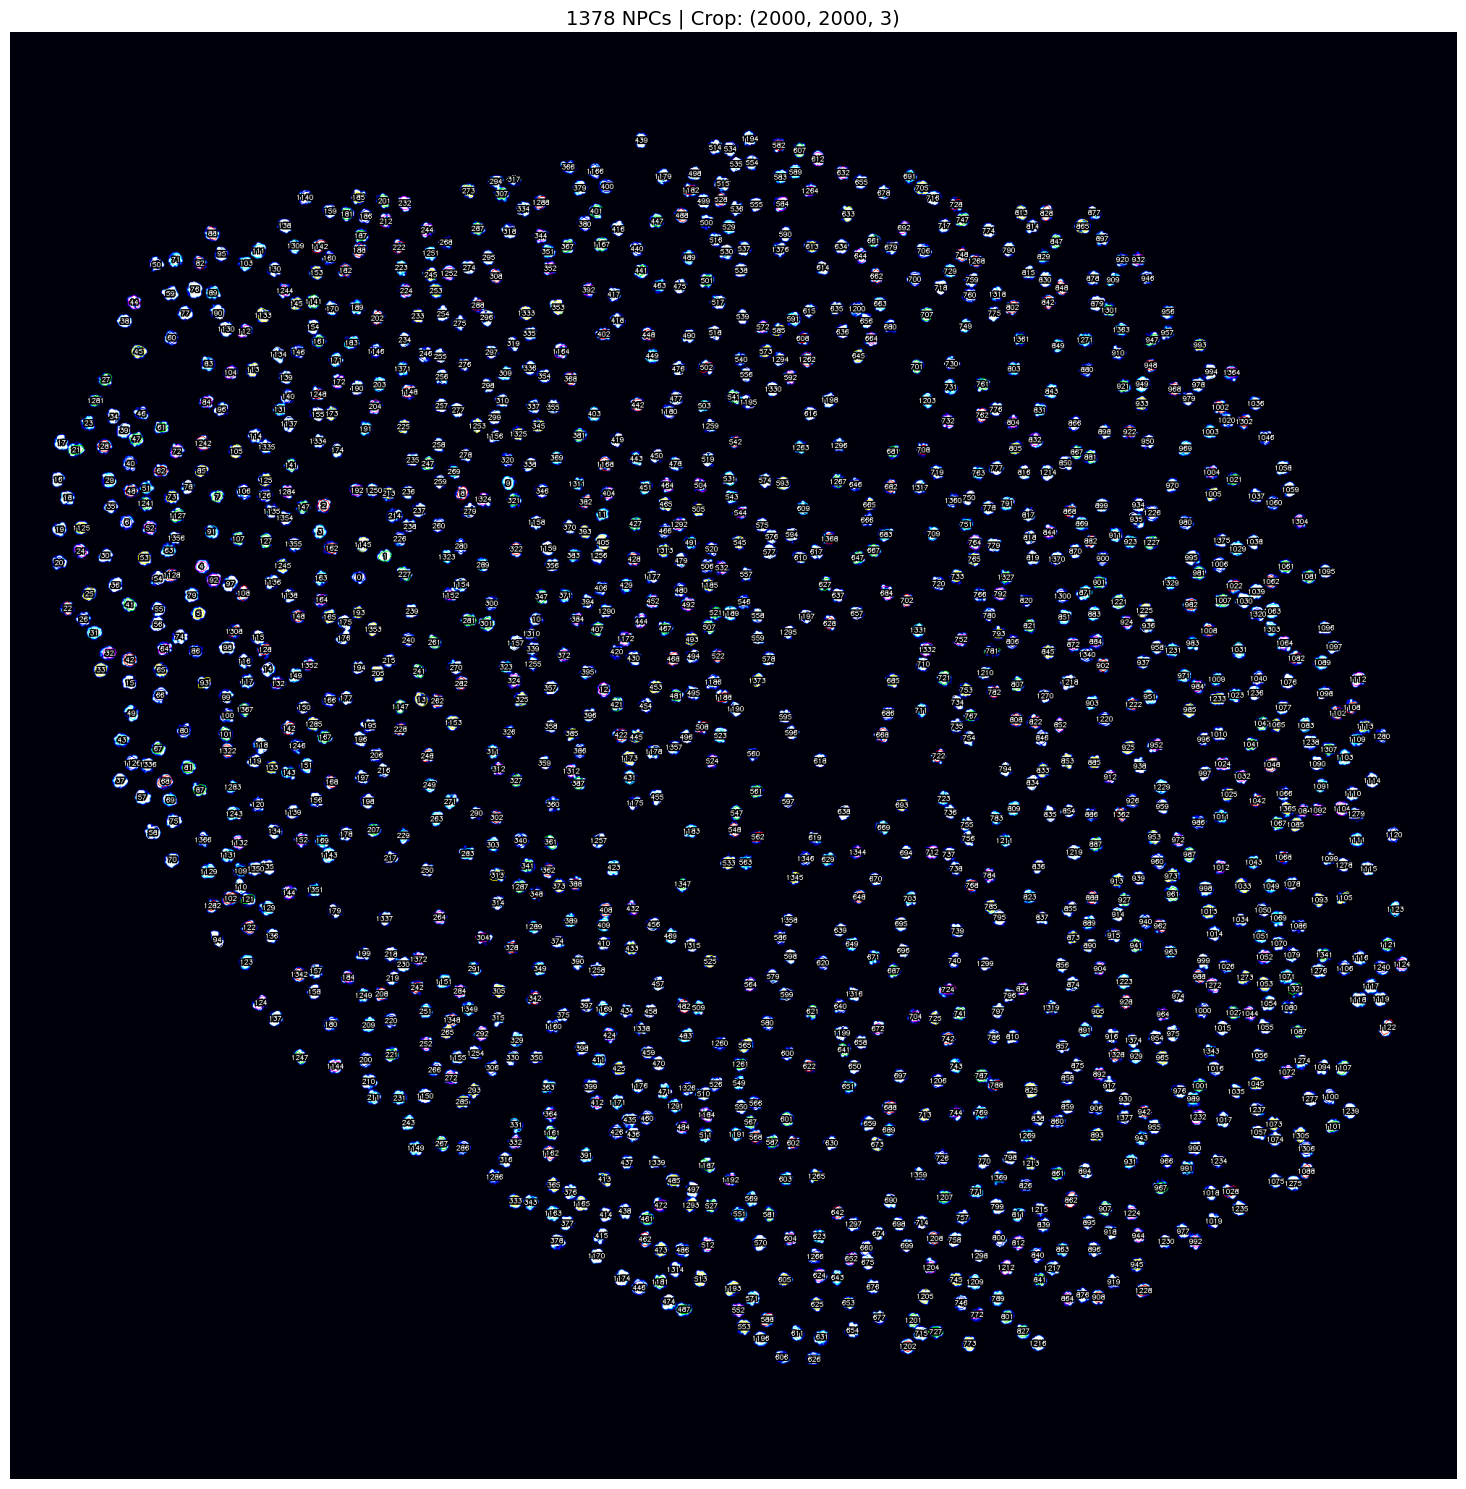

✅ Saved 2 files:
   npc_ellipses//npc_ellipses_1378_npcs.png (0.3 MB)
   npc_ellipses//npc_ellipses_1378_npcs.tif (48.0 MB)


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def draw_npc_ellipses_cv2(render_img, npc_features, oversampling=1.0, 
                         output_dir='output/', crop_y=(2300,4300), crop_x=(2400,4500),
                         thickness=1, font_scale=0.3, text_thickness=1, save_formats=['png', 'tif']):
    """
    Draw NPC ellipses on render image using OpenCV.
    
    Args:
        render_img: numpy array (grayscale or RGB)
        npc_features: DataFrame with ellipse columns
        oversampling: pixel scaling factor
        output_dir: save directory  
        crop_y, crop_x: (start, end) pixel coordinates for cropping
        thickness: ellipse line thickness
        save_formats: list of formats to save ['png', 'tif', 'jpg']
    """
    # Load your render image (keep original dtype)
    img = render_img.copy()  # numpy array

    # Convert to BGR if RGB/Grayscale (OpenCV uses BGR)
    if len(img.shape) == 2:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 3:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = img.copy()

    # Predefined 20 distinct colors (BGR format)
    colors = [
        (255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255),
        (0,255,255), (128,0,0), (0,128,0), (0,0,128), (128,128,0),
        (128,128,128), (255,128,0), (128,0,255), (0,128,255), (255,128,128),
        (128,255,128), (128,255,255), (255,255,128), (255,128,255), (64,64,64)
    ]
    
    # Draw ellipses for each NPC
    for i, row in npc_features.iterrows():
        # Scale coordinates to rendered pixels
        group_id = int(row.get('group_id', i))
        cx = int(row["ellipse_center_x"] * oversampling)
        cy = int(row["ellipse_center_y"] * oversampling)
        width = int(2 * row["ellipse_semi_major"] * oversampling)
        height = int(2 * row["ellipse_semi_minor"] * oversampling)
        angle = int(row["ellipse_angle_deg"])
        print(cx, cy, width, height, angle, oversampling)
        
        # Cycle through colors
        color = colors[i % len(colors)]
        
        # Draw filled ellipse outline (thickness=1, anti-aliased)
        cv2.ellipse(img_bgr, 
                   center=(cx, cy),
                   axes=(width//2, height//2),
                   angle=angle,
                   startAngle=0, endAngle=360,
                   color=color,
                   thickness=thickness,
                   lineType=cv2.LINE_AA)
    
    # 2. ADD GROUP ID TEXT AT ELLIPSE CENTER
         # Font for text
        font = cv2.FONT_HERSHEY_SIMPLEX
        text = str(group_id)
        text_color = (255, 255, 255)  # White text (high contrast)
        
        # Get text size for proper positioning
        (text_width, text_height), baseline = cv2.getTextSize(
            text, font, font_scale, text_thickness)
        
        # Position text at ellipse center (slightly offset for readability)
        text_x = cx - text_width // 2
        text_y = cy + text_height // 2
        
        # Draw white text with black outline for maximum readability
        cv2.putText(img_bgr, text, (text_x-1, text_y-1), 
                   font, font_scale, (0,0,0), text_thickness+1, cv2.LINE_AA)
        cv2.putText(img_bgr, text, (text_x+1, text_y+1), 
                   font, font_scale, (0,0,0), text_thickness+1, cv2.LINE_AA)
        cv2.putText(img_bgr, text, (text_x-1, text_y+1), 
                   font, font_scale, (0,0,0), text_thickness+1, cv2.LINE_AA)
        cv2.putText(img_bgr, text, (text_x+1, text_y-1), 
                   font, font_scale, (0,0,0), text_thickness+1, cv2.LINE_AA)
        cv2.putText(img_bgr, text, (text_x, text_y), 
                   font, font_scale, text_color, text_thickness, cv2.LINE_AA)
    

    
    # Convert back to original format
    if len(render_img.shape) == 2:
        result_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        result_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Create output directory
    Path(output_dir).mkdir(exist_ok=True)
    
    # Crop region
    crop_slice = slice(crop_y[0], crop_y[1]), slice(crop_x[0], crop_x[1])
    cropped = result_img[crop_slice]
    
    # Save in requested formats
    base_name = f'npc_ellipses_{len(npc_features)}_npcs'
    saved_files = []
    
    for fmt in save_formats:
        if fmt == 'png':
            cv2.imwrite(f'{output_dir}/{base_name}.png', cropped)
            saved_files.append(f'{output_dir}/{base_name}.png')
        elif fmt == 'tif':
            cv2.imwrite(f'{output_dir}/{base_name}.tif', cropped)
            saved_files.append(f'{output_dir}/{base_name}.tif')
        elif fmt == 'jpg':
            cv2.imwrite(f'{output_dir}/{base_name}.jpg', cropped, [cv2.IMWRITE_JPEG_QUALITY, 95])
            saved_files.append(f'{output_dir}/{base_name}.jpg')
    
    # Display preview
    plt.figure(figsize=(15,15))
    plt.imshow(cropped)
    plt.title(f'{len(npc_features)} NPCs | Crop: {cropped.shape}', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Saved {len(saved_files)} files:")
    for f in saved_files:
        print(f"   {f} ({Path(f).stat().st_size/1e6:.1f} MB)")
    
    return result_img, cropped, saved_files

result_img, cropped, files = draw_npc_ellipses_cv2(
    picked_render_img, npc_features, 
    oversampling=10.0,
    output_dir='npc_ellipses/',
    crop_y=(2300,4300), crop_x=(2450,4450),
    thickness=1,
    font_scale=0.3, text_thickness=1,
    save_formats=['png', 'tif']
)

The best ways to visualize feature differences depend on your NPC data dimensionality and questions

1. Summary statistics + distributions (Always first)

          group_id       n_locs     center_x     center_y  mean_radius  \
count  1378.000000  1378.000000  1378.000000  1378.000000  1378.000000   
mean    688.500000   631.769231   347.042755   324.605225     0.558228   
std     397.938647   147.552643    48.158348    43.553528     0.030340   
min       0.000000   320.000000   251.691406   244.778229     0.439838   
25%     344.250000   528.000000   307.651070   289.662819     0.536163   
50%     688.500000   616.000000   346.199036   321.507599     0.558358   
75%    1032.750000   735.000000   388.043671   361.096214     0.580240   
max    1377.000000  1231.000000   437.372131   413.481781     0.650209   

        radius_std  median_photons  median_precision  mean_ellipticity  \
count  1378.000000     1378.000000       1378.000000       1378.000000   
mean      0.212060     4327.708984          1.797552          0.061313   
std       0.037892      913.003784          0.071661          0.010544   
min       0.122298     1128.981689   

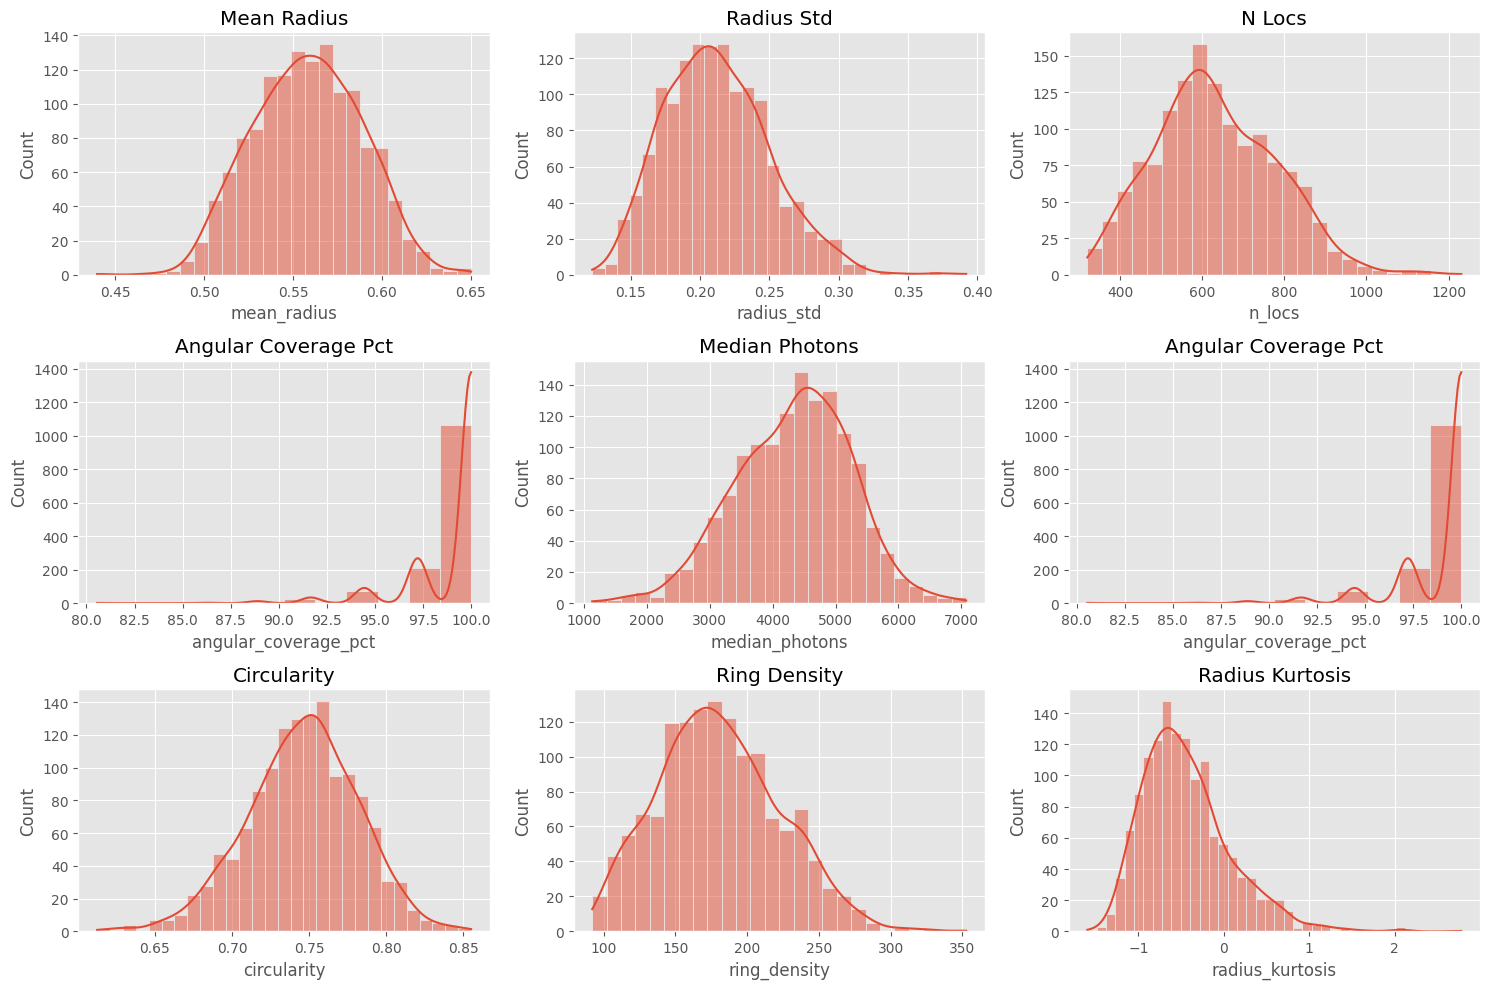

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Quick overview
print(npc_features.describe())

# Key feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
features = ['mean_radius', 'radius_std', 'n_locs', 'angular_coverage_pct', 'median_photons', 'angular_coverage_pct' , 'circularity',  'ring_density' , 'radius_kurtosis']

for i, feat in enumerate(features):
    ax = axes[i//3, i%3]
    sns.histplot(data=npc_features, x=feat, kde=True, ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
plt.tight_layout()
plt.show()
